### 이미지 처리

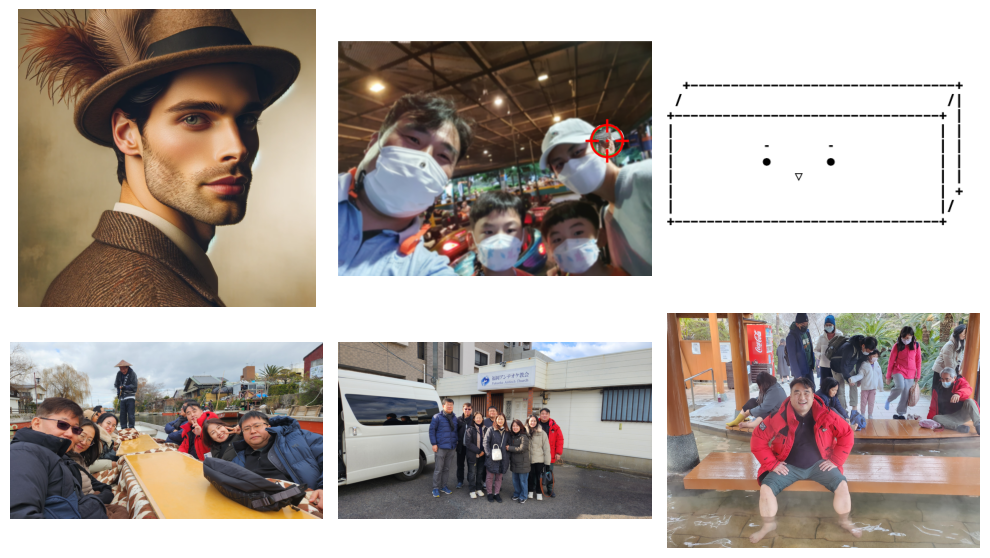

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2행 * 3열
## figsize=(10,6)  가로 10인치, 세로 6인치
fig, ax = plt.subplots(2,3, figsize=(10,6))

img00 = cv2.cvtColor(cv2.imread('../fff/like_lenna.png'), cv2.COLOR_BGR2RGB)
img01 = cv2.cvtColor(cv2.imread('../fff/back.png'), cv2.COLOR_BGR2RGB)
img02 = cv2.cvtColor(cv2.imread('../fff/box.png'), cv2.COLOR_BGR2RGB)
img10 = cv2.cvtColor(cv2.imread('../fff/CDCL8013.JPG'), cv2.COLOR_BGR2RGB)
img11 = cv2.cvtColor(cv2.imread('../fff/CXHA8530.JPG'), cv2.COLOR_BGR2RGB)
img12 = cv2.cvtColor(cv2.imread('../fff/MYMW7924.JPG'), cv2.COLOR_BGR2RGB)

## 각 셀의 이미지 설정
ax[0,0].imshow(img00) 
ax[0,1].imshow(img01) 
ax[0,2].imshow(img02) 
ax[1,0].imshow(img10) 
ax[1,1].imshow(img11) 
ax[1,2].imshow(img12) 



ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[1,0].axis('off')
ax[1,1].axis('off')
ax[1,2].axis('off')

# 셀간격 좁게
plt.tight_layout()
plt.show()


노이즈, 중앙필터

In [17]:
## 소금 노이즈 함수 정의
def generate_salt_noise(img):
    num_salt = np.ceil(0.05*img.size) ## 전체 픽셀수 5%를 노이즈로 사용
    
    coods = [   ## 난수 좌표 발생
        np.random.randint(0,i-1,int(num_salt))  ## 생성되는 원소들
        for i in img.shape   ##  반목문을 돌려서 새로운 배열 생성
    ]
    
    ret_img = img.copy()    ##원본복사
    ret_img[coods[0],coods[1]] = 255        ##난수 좌표의 색을 흰색으로 변경
    return ret_img

## 후추 노이즈
def generate_pepper_noise(img):
    nums = np.ceil(0.05*img.size) ## 전체 픽셀수 5%를 노이즈로 사용
    
    coods = [   ## 난수 좌표 발생
        np.random.randint(0,i-1,int(nums))  ## 생성되는 원소들
        for i in img.shape   ##  반목문을 돌려서 새로운 배열 생성
    ]
    
    ret_img = img.copy()    ##원본복사
    ret_img[coods[0],coods[1]] = 0
    ##난수 좌표의 색을 검은색으로 변경
    return ret_img

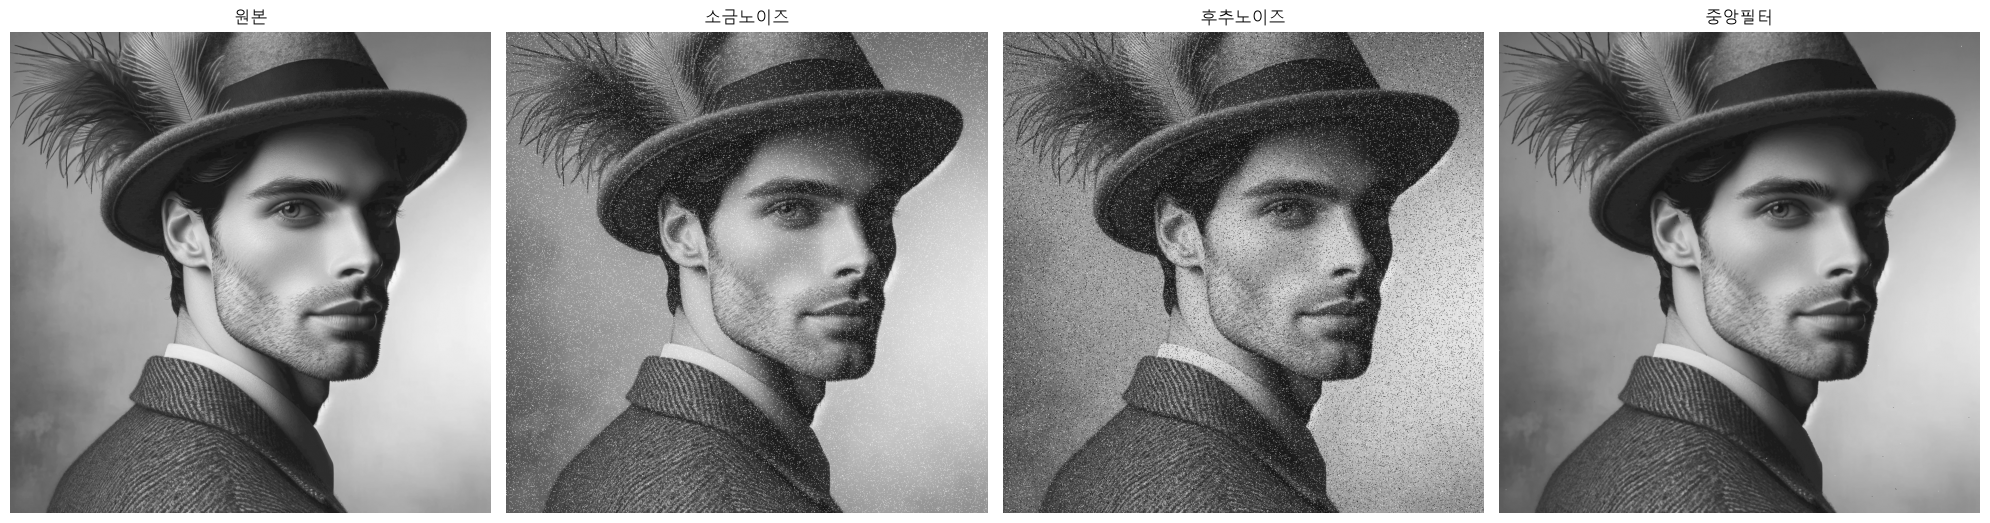

In [ ]:
## 원본이미지
ori_img = cv2.imread('../fff/like_lenna.png', cv2.IMREAD_GRAYSCALE)
cp_img = ori_img.copy()

fig, ax = plt.subplots(1,4, figsize=(20,6))  # 1*4 배열
plt.rc('font', family="Malgun Gothic")
plt.rcParams['axes.unicode_minus']

ax[0].imshow(ori_img, cmap='gray')
ax[0].set_title('원본')

## 노이즈 추가1
salt_img = generate_salt_noise(ori_img)
ax[1].imshow(salt_img, cmap='gray')
ax[1].set_title('소금노이즈')

#노이즈 추가2
pepper_img = generate_pepper_noise(salt_img)
ax[2].imshow(pepper_img, cmap='gray')
ax[2].set_title('후추노이즈')

# 노이즈 제거
filter_img = cv2.medianBlur(pepper_img, 3)
ax[3].imshow(filter_img, cmap='gray')
ax[3].set_title('중앙필터')

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].axis('off')
plt.tight_layout()
plt.show()


가우시안 필터

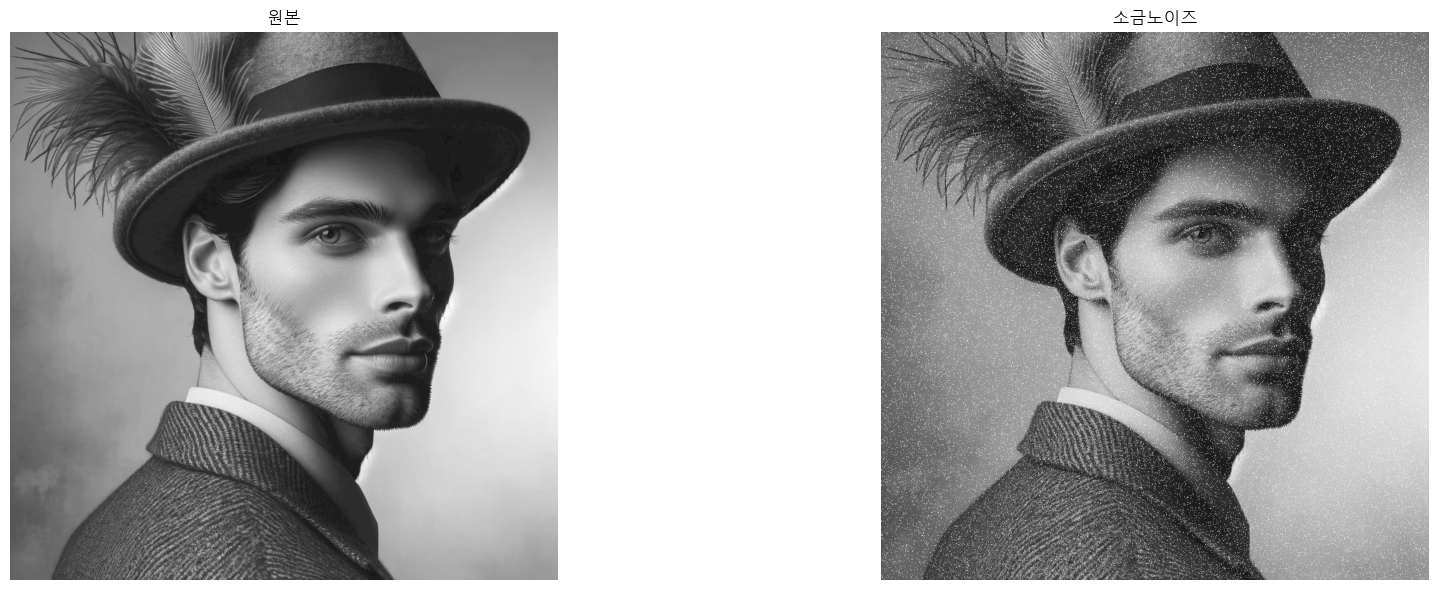

In [ ]:
## 원본이미지
ori_img = cv2.imread('../fff/like_lenna.png', cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1,2, figsize=(20,6))  # 1*4 배열
plt.rc('font', family="Malgun Gothic")
plt.rcParams['axes.unicode_minus']

ax[0].imshow(ori_img, cmap='gray')
ax[0].set_title('원본')

## 노이즈 추가

salt_img = generate_salt_noise(ori_img)
ax[1].imshow(salt_img, cmap='gray')
ax[1].set_title('소금노이즈')

ax[0].axis('off')
ax[1].axis('off')

plt.tight_layout()
plt.show()